In [18]:
from utils import *

In [19]:
metadata = load_dataset_metadata("../data/sudoku_trace_dataset")


In [20]:
problem = metadata['problems'][0]
print(problem)



{'problem_id': 0, 'sudoku_input': [[0, 0, 5, 0, 0, 0, 0, 0, 4], [6, 0, 0, 0, 3, 0, 0, 9, 0], [0, 4, 0, 0, 0, 2, 0, 0, 0], [5, 0, 0, 0, 9, 0, 0, 6, 0], [0, 0, 0, 7, 0, 8, 0, 0, 0], [0, 0, 7, 0, 0, 0, 8, 0, 2], [0, 3, 0, 0, 1, 0, 5, 0, 0], [1, 0, 0, 0, 0, 9, 0, 0, 6], [0, 5, 0, 0, 0, 0, 0, 1, 0]], 'sudoku_target': [[3, 9, 5, 1, 6, 7, 2, 8, 4], [6, 7, 2, 8, 3, 4, 1, 9, 5], [8, 4, 1, 9, 5, 2, 6, 7, 3], [5, 2, 8, 3, 9, 1, 4, 6, 7], [4, 6, 3, 7, 2, 8, 9, 5, 1], [9, 1, 7, 6, 4, 5, 8, 3, 2], [7, 3, 9, 2, 1, 6, 5, 4, 8], [1, 8, 4, 5, 7, 9, 3, 2, 6], [2, 5, 6, 4, 8, 3, 7, 1, 9]], 'metadata': {'steps_taken': 16, 'halted': True, 'batch_id': 0, 'sample_in_batch': 0, 'is_correct': True, 'accuracy': 1.0, 'correct_cells': 81, 'valid_sudoku': True, 'final_prediction': [[3, 9, 5, 1, 6, 7, 2, 8, 4], [6, 7, 2, 8, 3, 4, 1, 9, 5], [8, 4, 1, 9, 5, 2, 6, 7, 3], [5, 2, 8, 3, 9, 1, 4, 6, 7], [4, 6, 3, 7, 2, 8, 9, 5, 1], [9, 1, 7, 6, 4, 5, 8, 3, 2], [7, 3, 9, 2, 1, 6, 5, 4, 8], [1, 8, 4, 5, 7, 9, 3, 2, 6], [2, 5

In [21]:
problem = create_problem_tensors(problem, "../data/")
labels, X_reduced = segment_l_phases(problem)


/home/calebkaiser/Code/HRM/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/calebkaiser/Code/HRM/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


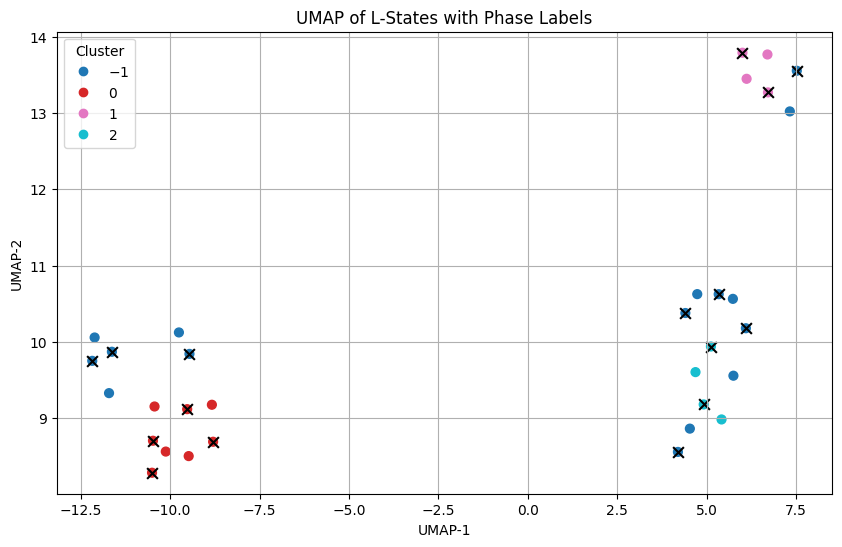

In [22]:
plot_umap_with_labels(X_reduced, labels, problem['is_h_update'])


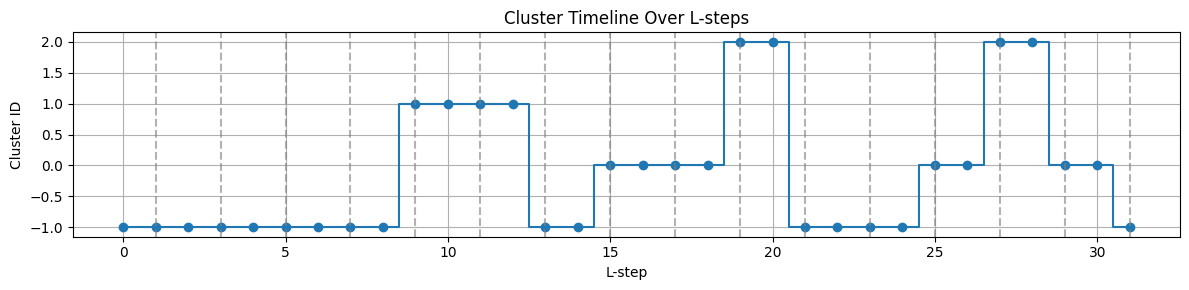

In [23]:
plot_cluster_timeline(labels, problem['is_h_update'])


In [24]:
grids = extract_predicted_grids(problem['vocab_logits'])

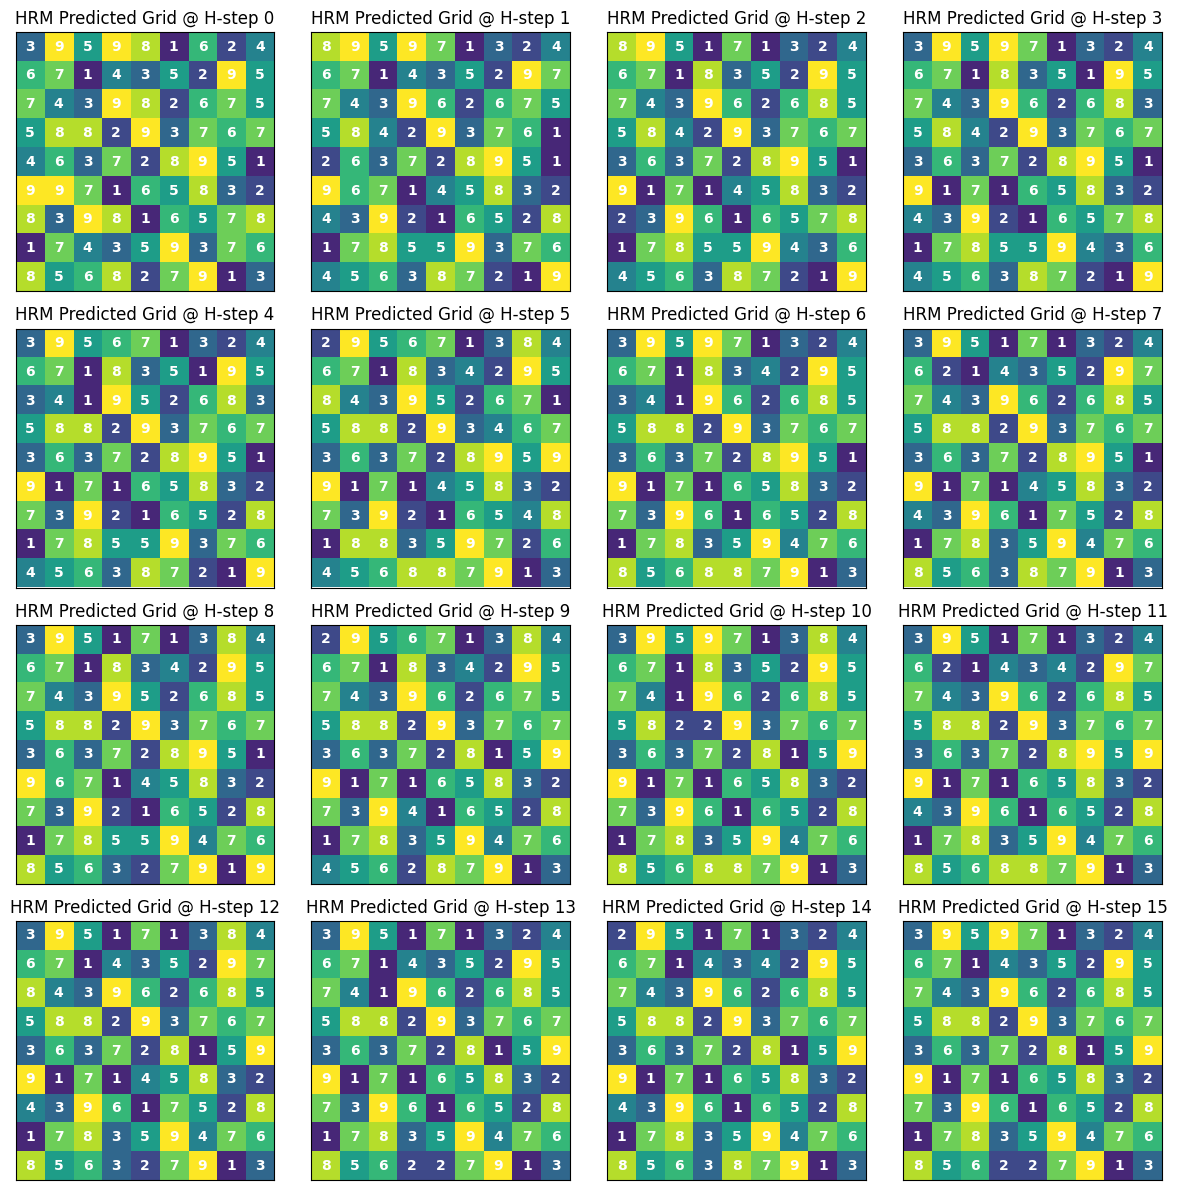

In [25]:
visualize_sudoku_grids_over_time(grids)

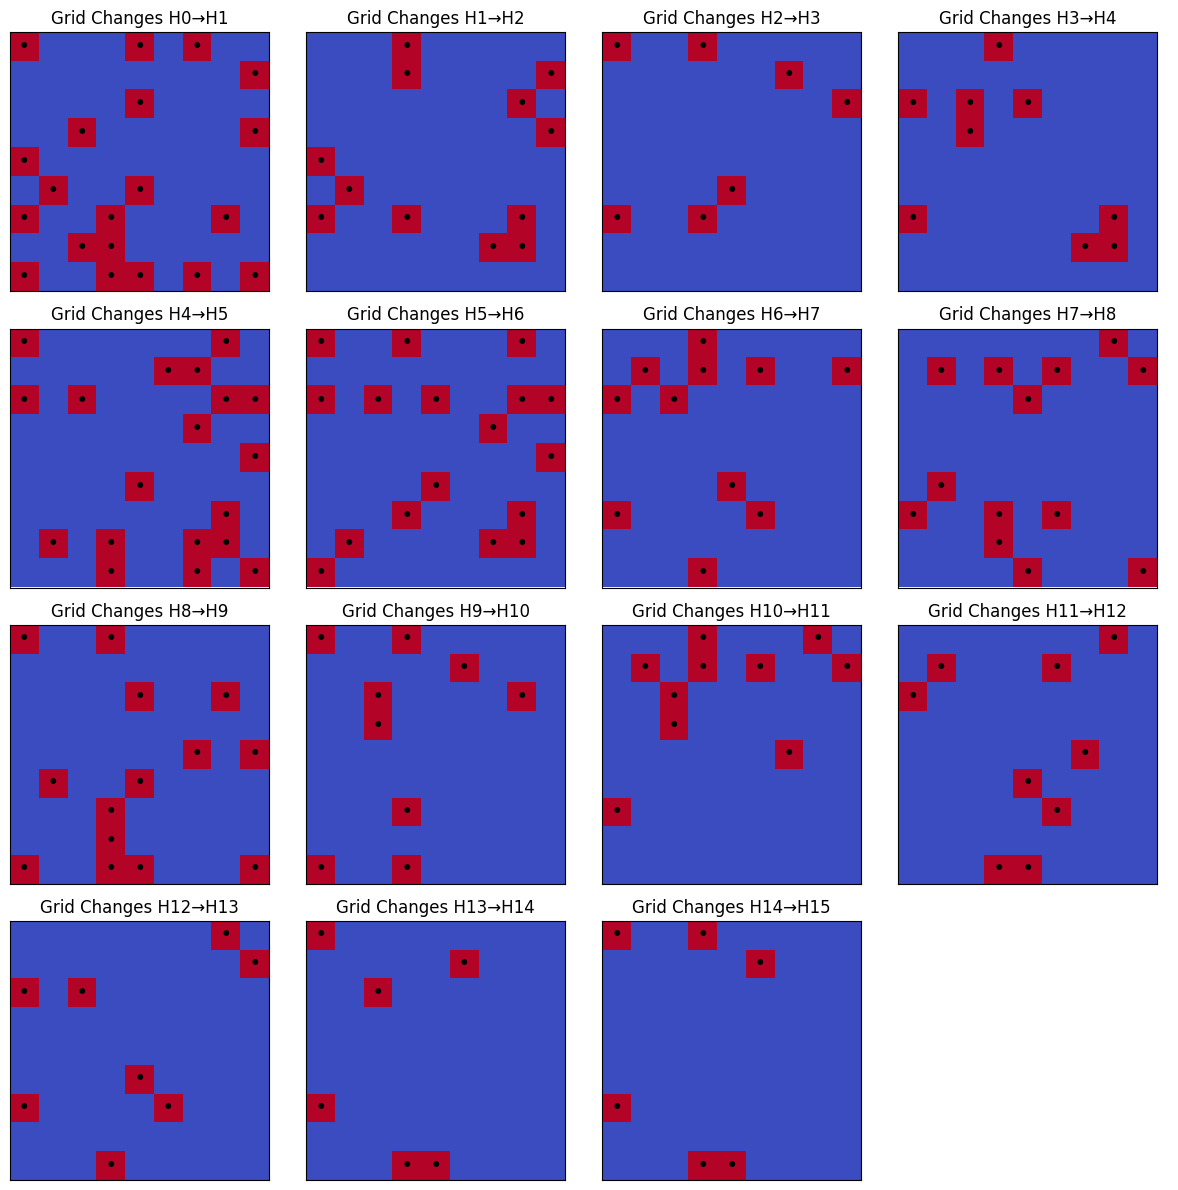

In [26]:
visualize_grid_deltas(grids)

In [27]:
# Ruptures

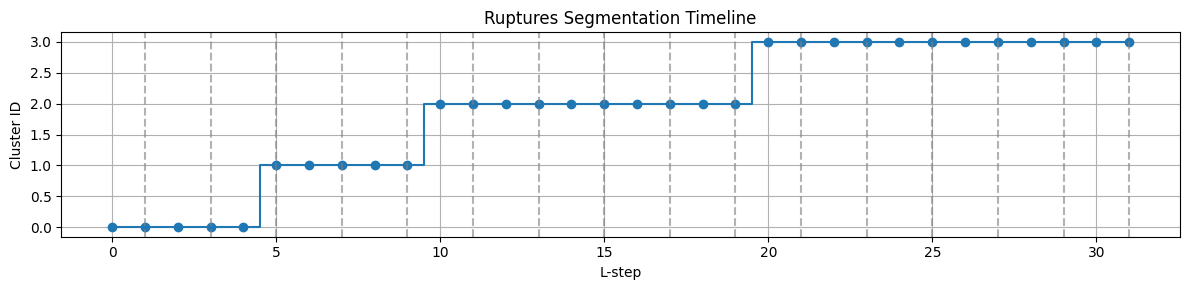

In [28]:
outputs = segment_l_phases_rupture(problem)

In [29]:
hundred_problems = load_problems_to_tensors("../data/sudoku_trace_dataset")

In [30]:
clustered_tensors = cluster_segments(hundred_problems)

In [31]:
h_deltas = extract_h_step_deltas(clustered_tensors)

outer loop
decoded
[[3 9 5 9 8 1 6 2 4]
 [6 7 1 4 3 5 2 9 5]
 [7 4 3 9 8 2 6 7 5]
 [5 8 8 2 9 3 7 6 7]
 [4 6 3 7 2 8 9 5 1]
 [9 9 7 1 6 5 8 3 2]
 [8 3 9 8 1 6 5 7 8]
 [1 7 4 3 5 9 3 7 6]
 [8 5 6 8 2 7 9 1 3]]
outer loop
decoded
[[3 9 5 9 8 1 6 2 4]
 [6 7 1 4 3 5 2 9 5]
 [7 4 3 9 8 2 6 7 5]
 [5 8 8 2 9 3 7 6 7]
 [4 6 3 7 2 8 9 5 1]
 [9 9 7 1 6 5 8 3 2]
 [8 3 9 8 1 6 5 7 8]
 [1 7 4 3 5 9 3 7 6]
 [8 5 6 8 2 7 9 1 3]]
outer loop
decoded
[[3 9 5 9 8 1 6 2 4]
 [6 7 1 4 3 5 2 9 5]
 [7 4 3 9 8 2 6 7 5]
 [5 8 8 2 9 3 7 6 7]
 [4 6 3 7 2 8 9 5 1]
 [9 9 7 1 6 5 8 3 2]
 [8 3 9 8 1 6 5 7 8]
 [1 7 4 3 5 9 3 7 6]
 [8 5 6 8 2 7 9 1 3]]
outer loop
decoded
[[3 9 5 9 8 1 6 2 4]
 [6 7 1 4 3 5 2 9 5]
 [7 4 3 9 8 2 6 7 5]
 [5 8 8 2 9 3 7 6 7]
 [4 6 3 7 2 8 9 5 1]
 [9 9 7 1 6 5 8 3 2]
 [8 3 9 8 1 6 5 7 8]
 [1 7 4 3 5 9 3 7 6]
 [8 5 6 8 2 7 9 1 3]]
outer loop
decoded
[[9 4 1 3 8 7 5 2 6]
 [8 4 3 3 2 1 9 7 1]
 [5 7 9 4 6 1 7 8 2]
 [7 3 8 1 4 2 6 5 9]
 [4 5 9 6 8 3 6 1 7]
 [1 6 3 5 7 5 8 9 8]
 [3 1 7 2 4 8 1 6 9

In [36]:
plot_delta_heatmap([torch.from_numpy(h_delta) for h_delta in h_deltas])

TypeError: expected np.ndarray (got numpy.int32)

In [33]:
list(h_deltas)

[np.int32(3),
 np.int32(8),
 np.int32(5),
 np.int32(4),
 np.int32(1),
 np.int32(2),
 np.int32(6),
 np.int32(7),
 np.int32(0),
 np.int32(9)]

In [ ]:
clustered_tensors